# Installing the package

Uncomment this line to download the package. For best results, install PyVaR in a fresh Python environment to avoid conflicts with existing packages.

In [1]:
#pip install git+https://github.com/Alessandro-Dodon/pyvar.git#subdirectory=package

---

## Notebook Overview

This notebook provides a hands-on introduction to **Extreme Value Theory (EVT)** for portfolio risk management. We explore EVT in two key applications:

1. A **basic univariate setting**, using a single ETF position to illustrate tail modeling and threshold selection.
2. An **advanced simulation-based application**, where EVT is combined with Monte Carlo methods to estimate **VaR at extremely high confidence levels** (e.g., 99.97%).

For each case, we review the main concepts, such as the Generalized Pareto Distribution (GPD), then show how to implement EVT using our Python package and example data.


### Packages

We begin by importing the `pyvar` package along with other necessary libraries for data handling, analysis, and visualization. Ensure all required packages are installed in your environment before proceeding.

In [2]:
import pyvar as pv

In [3]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

---

## Part I: Univariate EVT with a Single Asset

We start with a simple, transparent setting to introduce Extreme Value Theory: modeling tail risk for a **single asset** — the Vanguard Total World Stock ETF (VT). This ETF serves as a well-diversified proxy for global equity markets and allows us to focus on EVT mechanics without portfolio complications.

Note: All models in this section are based on **daily return data**.

Feel free to replace the ticker with another asset of interest. Popular choices include:
- S&P 500 Index (`SPY`)
- Apple (`AAPL`)
- Nvidia (`NVDA`)
- Microsoft (`MSFT`)
- Tesla (`TSLA`)

In [4]:
# Download the VT data from YF
vt_data = yf.download("VT", start="2000-01-01", end="2025-01-01")

# Check for missing values in the entire DataFrame (including the new column)
print(vt_data.isnull().sum())

YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed

Price   Ticker
Close   VT        0
High    VT        0
Low     VT        0
Open    VT        0
Volume  VT        0
dtype: int64


In [5]:
# Compute percentage returns and remove the first NaN
vt_data["Percent Returns"] = vt_data["Close"].pct_change()
vt_returns = vt_data["Percent Returns"].dropna()

In [6]:
vt_returns.head()

Date
2008-06-27   -0.001614
2008-06-30    0.000808
2008-07-01   -0.008882
2008-07-02   -0.014664
2008-07-03    0.002687
Name: Percent Returns, dtype: float64

If you want to **download and save the return series as a CSV**, you can do:

```python
vt_returns.to_csv("vt_returns.csv")
```

If you want to **load your own return series from a CSV**, use:

```python
vt_returns = pd.read_csv("your_file.csv", index_col=0, parse_dates=True).squeeze()
```

Make sure:
- The CSV contains one column of daily return values
- The first column becomes the date index
- Dates are properly parsed for the analysis
- Returns are already computed (not prices)

Note: You are responsible for return calculation and data cleaning.  

---


### EVT Introduction

Extreme Value Theory provides a parametric framework to estimate tail risk by modeling the extreme values beyond a high threshold. It is especially useful when data is scarce or when high-confidence VaRs are needed.

The fitted distribution in the tail is controlled by two parameters:  
- ξ (shape): tail heaviness  
- β (scale): dispersion

EVT VaR (confidence level c) is defined as:

$$
{\text{VaR}_\alpha} = u + \frac{{\beta}}{{\xi}} \left[ \left( \frac{n}{n_u}(1 - c) \right)^{-{\xi}} - 1 \right]
$$

EVT ES is defined as:

$$
{\text{ES}_\alpha} = \frac{{VaR}_\alpha+ {\beta} - {\xi} u}{1 - {\xi}}
$$



This method often improves risk estimates over pure historical simulation by focusing on the distribution's most extreme observations.


In [7]:
# General parameters
confidence_level = 0.99 # <----- Can choose 0.95 etc
wealth=100_000 # <----- Wealth invested in our ETF

In [8]:
# EVT parameter
threshold_percentile=97.5 # <----- Can choose 95 etc 

In [9]:
# Apply EVT model
evt_results = pv.evt_var(
    returns=vt_returns, 
    confidence_level=confidence_level, 
    threshold_percentile=threshold_percentile,
    wealth=wealth
    )

# ES
evt_results = pv.evt_es(
    result_data=evt_results,
    threshold_percentile=threshold_percentile,
    wealth=wealth
    )


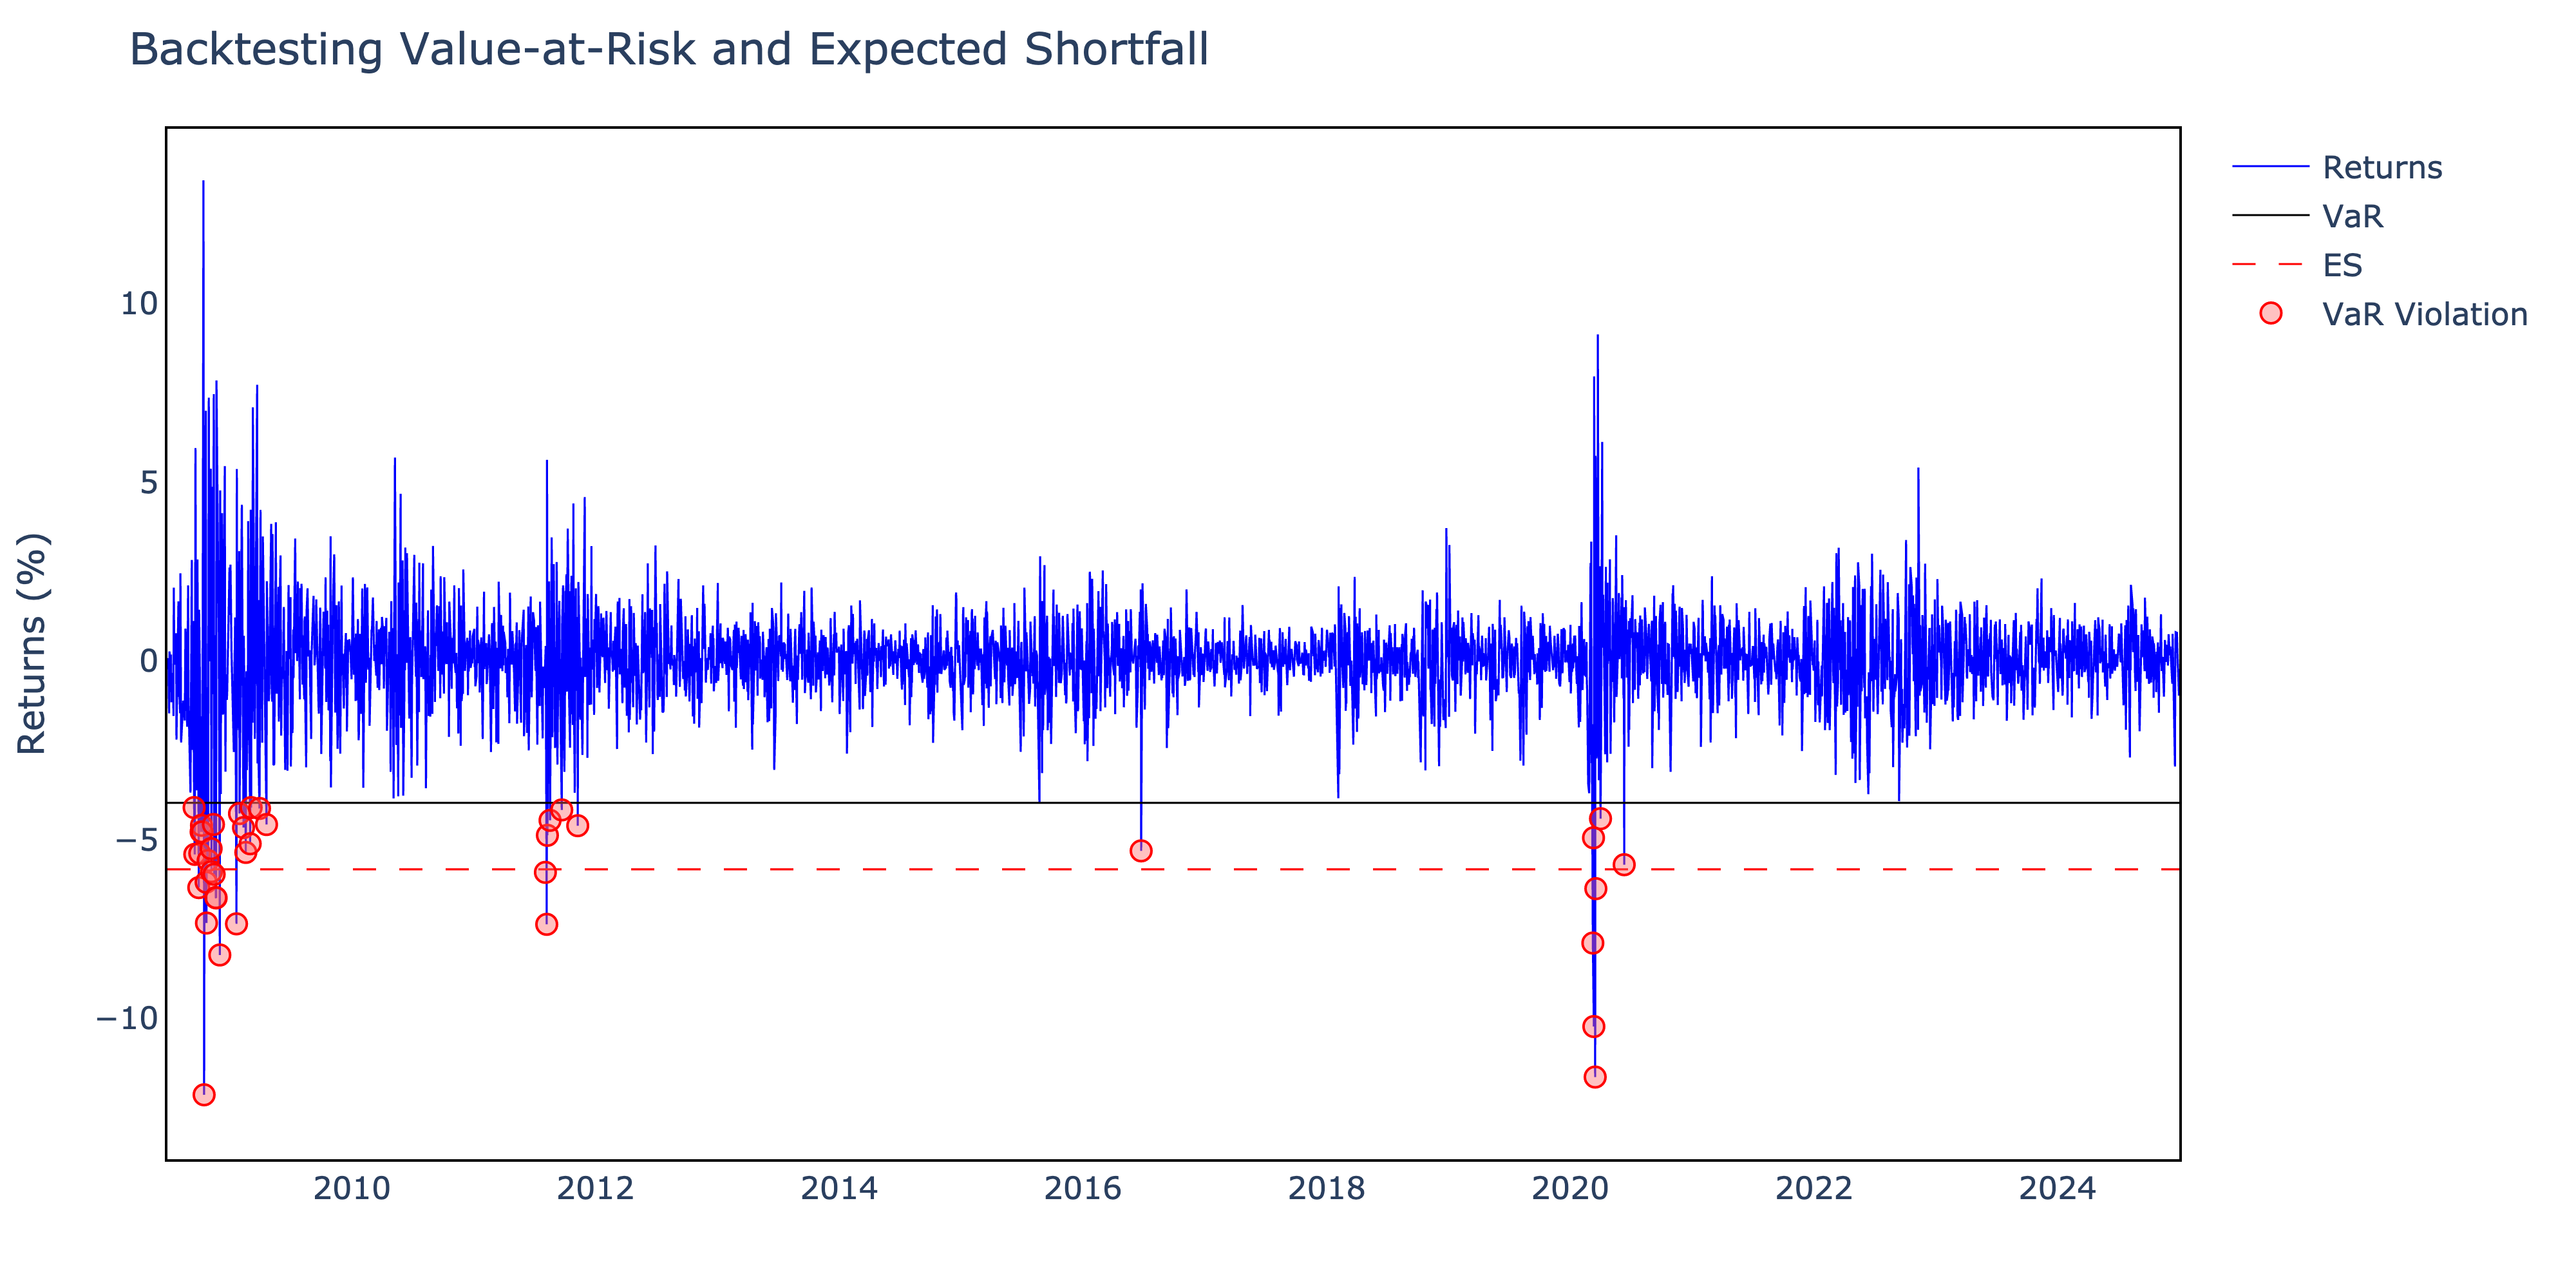

In [10]:
# Plot backtest
pv.plot_backtest(evt_results, interactive=False)

In [11]:
evt_results.head()

,Returns,VaR,VaR Violation,VaR_monetary,ES,ES_monetary
Date,,,,,,
2008-06-27,-0.001614,0.039687,False,3968.711408,0.058276,5827.622893
2008-06-30,0.000808,0.039687,False,3968.711408,0.058276,5827.622893
2008-07-01,-0.008882,0.039687,False,3968.711408,0.058276,5827.622893
2008-07-02,-0.014664,0.039687,False,3968.711408,0.058276,5827.622893
2008-07-03,0.002687,0.039687,False,3968.711408,0.058276,5827.622893


#### Backtesting EVT

Notice how, despite the very high precision in matching the total number of violations, the EVT model is **not time-varying**, and thus fails the **Christoffersen independence test** — indicating that violations are not randomly distributed over time.

In [12]:
# Count violations
evt_violations, evt_violation_rate = pv.count_violations(evt_results)

# Kupiec Test (Unconditional Coverage)
evt_kupiec = pv.kupiec_test(
    total_violations=evt_violations,
    total_days=len(evt_results),
    confidence_level=confidence_level
)

# Christoffersen Test (Independence)
evt_christoffersen = pv.christoffersen_test(evt_results)

# Joint Test (Conditional Coverage)
evt_joint = pv.joint_lr_test(
    LR_uc=evt_kupiec["LR_uc"],
    LR_c=evt_christoffersen["LR_c"]
)

In [13]:
# Summary output
print(f"\n--- EVT VaR Backtesting Summary ---")
print(f"Total Violations     : {evt_violations}")
print(f"Violation Rate       : {evt_violation_rate * 100:.2f}%\n")

print("Kupiec Test (UC):")
print(f"LR_uc               : {evt_kupiec['LR_uc']:.4f}")
print(f"p-value             : {evt_kupiec['p_value']:.4f}")
print(f"Reject Null (5%)    : {evt_kupiec['reject_null']}")

print("\nChristoffersen Test (Independence):")
print(f"LR_c                : {evt_christoffersen['LR_c']:.4f}")
print(f"p-value             : {evt_christoffersen['p_value']:.4f}")
print(f"Reject Null (5%)    : {evt_christoffersen['reject_null']}")

print("\nJoint Test (Conditional Coverage):")
print(f"LR_total            : {evt_joint['LR_total']:.4f}")
print(f"p-value             : {evt_joint['p_value']:.4f}")
print(f"Reject Null (5%)    : {evt_joint['reject_null']}")


--- EVT VaR Backtesting Summary ---
Total Violations     : 40
Violation Rate       : 0.96%

Kupiec Test (UC):
LR_uc               : 0.0599
p-value             : 0.8067
Reject Null (5%)    : False

Christoffersen Test (Independence):
LR_c                : 17.5324
p-value             : 0.0000
Reject Null (5%)    : True

Joint Test (Conditional Coverage):
LR_total            : 17.5923
p-value             : 0.0002
Reject Null (5%)    : True


---

## Part 2: Combining EVT and Simulation Methods

In this section, we apply **WHS** and **FHS** simulation methods to a sample equity and options portfolio to generate the 1-day profit-and-loss distribution. We then use **Extreme Value Theory (EVT)** to extract **tail-based VaR and ES** estimates from the simulated losses, focusing on extreme quantiles beyond the 99% level.

Our package provides simple functions to automatically build your portfolio: prices are downloaded from Yahoo Finance, you specify the number of shares, and optionally convert everything to your base currency (CHF in our case). Those are particularly useful to check common problems like missing values, stability of the VCV matrix etc.

Our example portfolio follows a stylized global equity strategy:  
- Long positions in broad market, regional, and sector ETFs (VT, SPY, VGK, EWJ, VWO)  
- Exposure to leading firms in tech, healthcare, and consumer sectors (AAPL, JNJ, PG, UNH, NVS)  
- A small short position in industrials (XLI) to hedge against cyclical downturns

We assume a **buy-and-hold** or "lazy portfolio" strategy. No active trading or rebalancing is considered. If the portfolio composition changes, all subsequent VaR and ES metrics must be recomputed from that point onward.

In [14]:
# Define shares — globally diversified portfolio
shares = pd.Series({
    "VT": 120,     # Global equity ETF
    "SPY": 80,     # US large-cap ETF
    "VGK": 60,     # Europe ETF
    "EWJ": 40,     # Japan ETF
    "VWO": 60,     # Emerging Markets ETF
    "AAPL": 50,    # Apple — tech
    "JNJ": 50,     # Johnson & Johnson — healthcare
    "PG": 40,      # Procter & Gamble — consumer staples
    "UNH": 40,     # UnitedHealth — healthcare
    "NVS": 30,     # Novartis — Swiss healthcare
    "XLI": -30     # US industrials sector ETF — short hedge
})

# Download prices and convert to base currency
tickers = shares.index.tolist()
raw_prices = pv.get_raw_prices(tickers, start="2023-01-01", end="2025-01-01")
prices_chf = pv.convert_to_base_currency(raw_prices, base_currency="CHF")

# Compute monetary position values over time
portfolio_matrix = pv.create_portfolio(prices_chf, shares)

# Compute portfolio returns and statistics
portfolio_returns = pv.compute_returns(portfolio_matrix)

[currency detection] AAPL: USD
[currency detection] EWJ: USD
[currency detection] JNJ: USD
[currency detection] NVS: USD
[currency detection] PG: USD
[currency detection] SPY: USD
[currency detection] UNH: USD
[currency detection] VGK: USD
[currency detection] VT: USD
[currency detection] VWO: USD
[currency detection] XLI: USD
[fx download] Downloading FX pairs: CHFUSD=X
[conversion] AAPL: USD → CHF via CHFUSD=X
[conversion] EWJ: USD → CHF via CHFUSD=X
[conversion] JNJ: USD → CHF via CHFUSD=X
[conversion] NVS: USD → CHF via CHFUSD=X
[conversion] PG: USD → CHF via CHFUSD=X
[conversion] SPY: USD → CHF via CHFUSD=X
[conversion] UNH: USD → CHF via CHFUSD=X
[conversion] VGK: USD → CHF via CHFUSD=X
[conversion] VT: USD → CHF via CHFUSD=X
[conversion] VWO: USD → CHF via CHFUSD=X
[conversion] XLI: USD → CHF via CHFUSD=X


In [15]:
prices_chf.tail()

,AAPL,EWJ,JNJ,NVS,PG,SPY,UNH,VGK,VT,VWO,XLI
Date,,,,,,,,,,,
2024-12-24,231.426704,59.223917,128.896222,85.194986,149.932985,537.041999,449.589076,56.368561,106.685954,40.067612,119.804971
2024-12-26,232.407133,59.973532,128.793635,85.328432,151.175422,537.645712,454.555311,56.578238,106.923679,40.011427,120.021037
2024-12-27,229.196950,60.393619,128.250552,85.270424,150.528611,531.678524,453.261519,56.360245,106.023655,39.845030,119.058198
2024-12-30,226.896712,60.081229,127.153121,84.627656,148.847343,527.330344,452.791238,56.172810,105.341614,39.625007,118.246502
2024-12-31,225.645065,60.120737,128.487744,84.741616,149.578060,526.227574,451.761624,56.268884,105.263231,39.623541,118.286434


In [16]:
# Compute latest portfolio value and weights
latest_prices = prices_chf.iloc[-1]
portfolio_value_chf = (shares * latest_prices).sum()
weights = (shares * latest_prices) / portfolio_value_chf

# Print final portfolio value and weights
print(f"\nFinal portfolio value in CHF: {portfolio_value_chf:,.2f}\n")
print("Portfolio weights (based on latest prices):")
print(weights.round(4).sort_values(ascending=False))


Final portfolio value in CHF: 103,642.05

Portfolio weights (based on latest prices):
SPY     0.4062
UNH     0.1744
VT      0.1219
AAPL    0.1089
JNJ     0.0620
PG      0.0577
VGK     0.0326
NVS     0.0245
EWJ     0.0232
VWO     0.0229
XLI    -0.0342
dtype: float64


A quick way to observe the correlations of our portfolio!


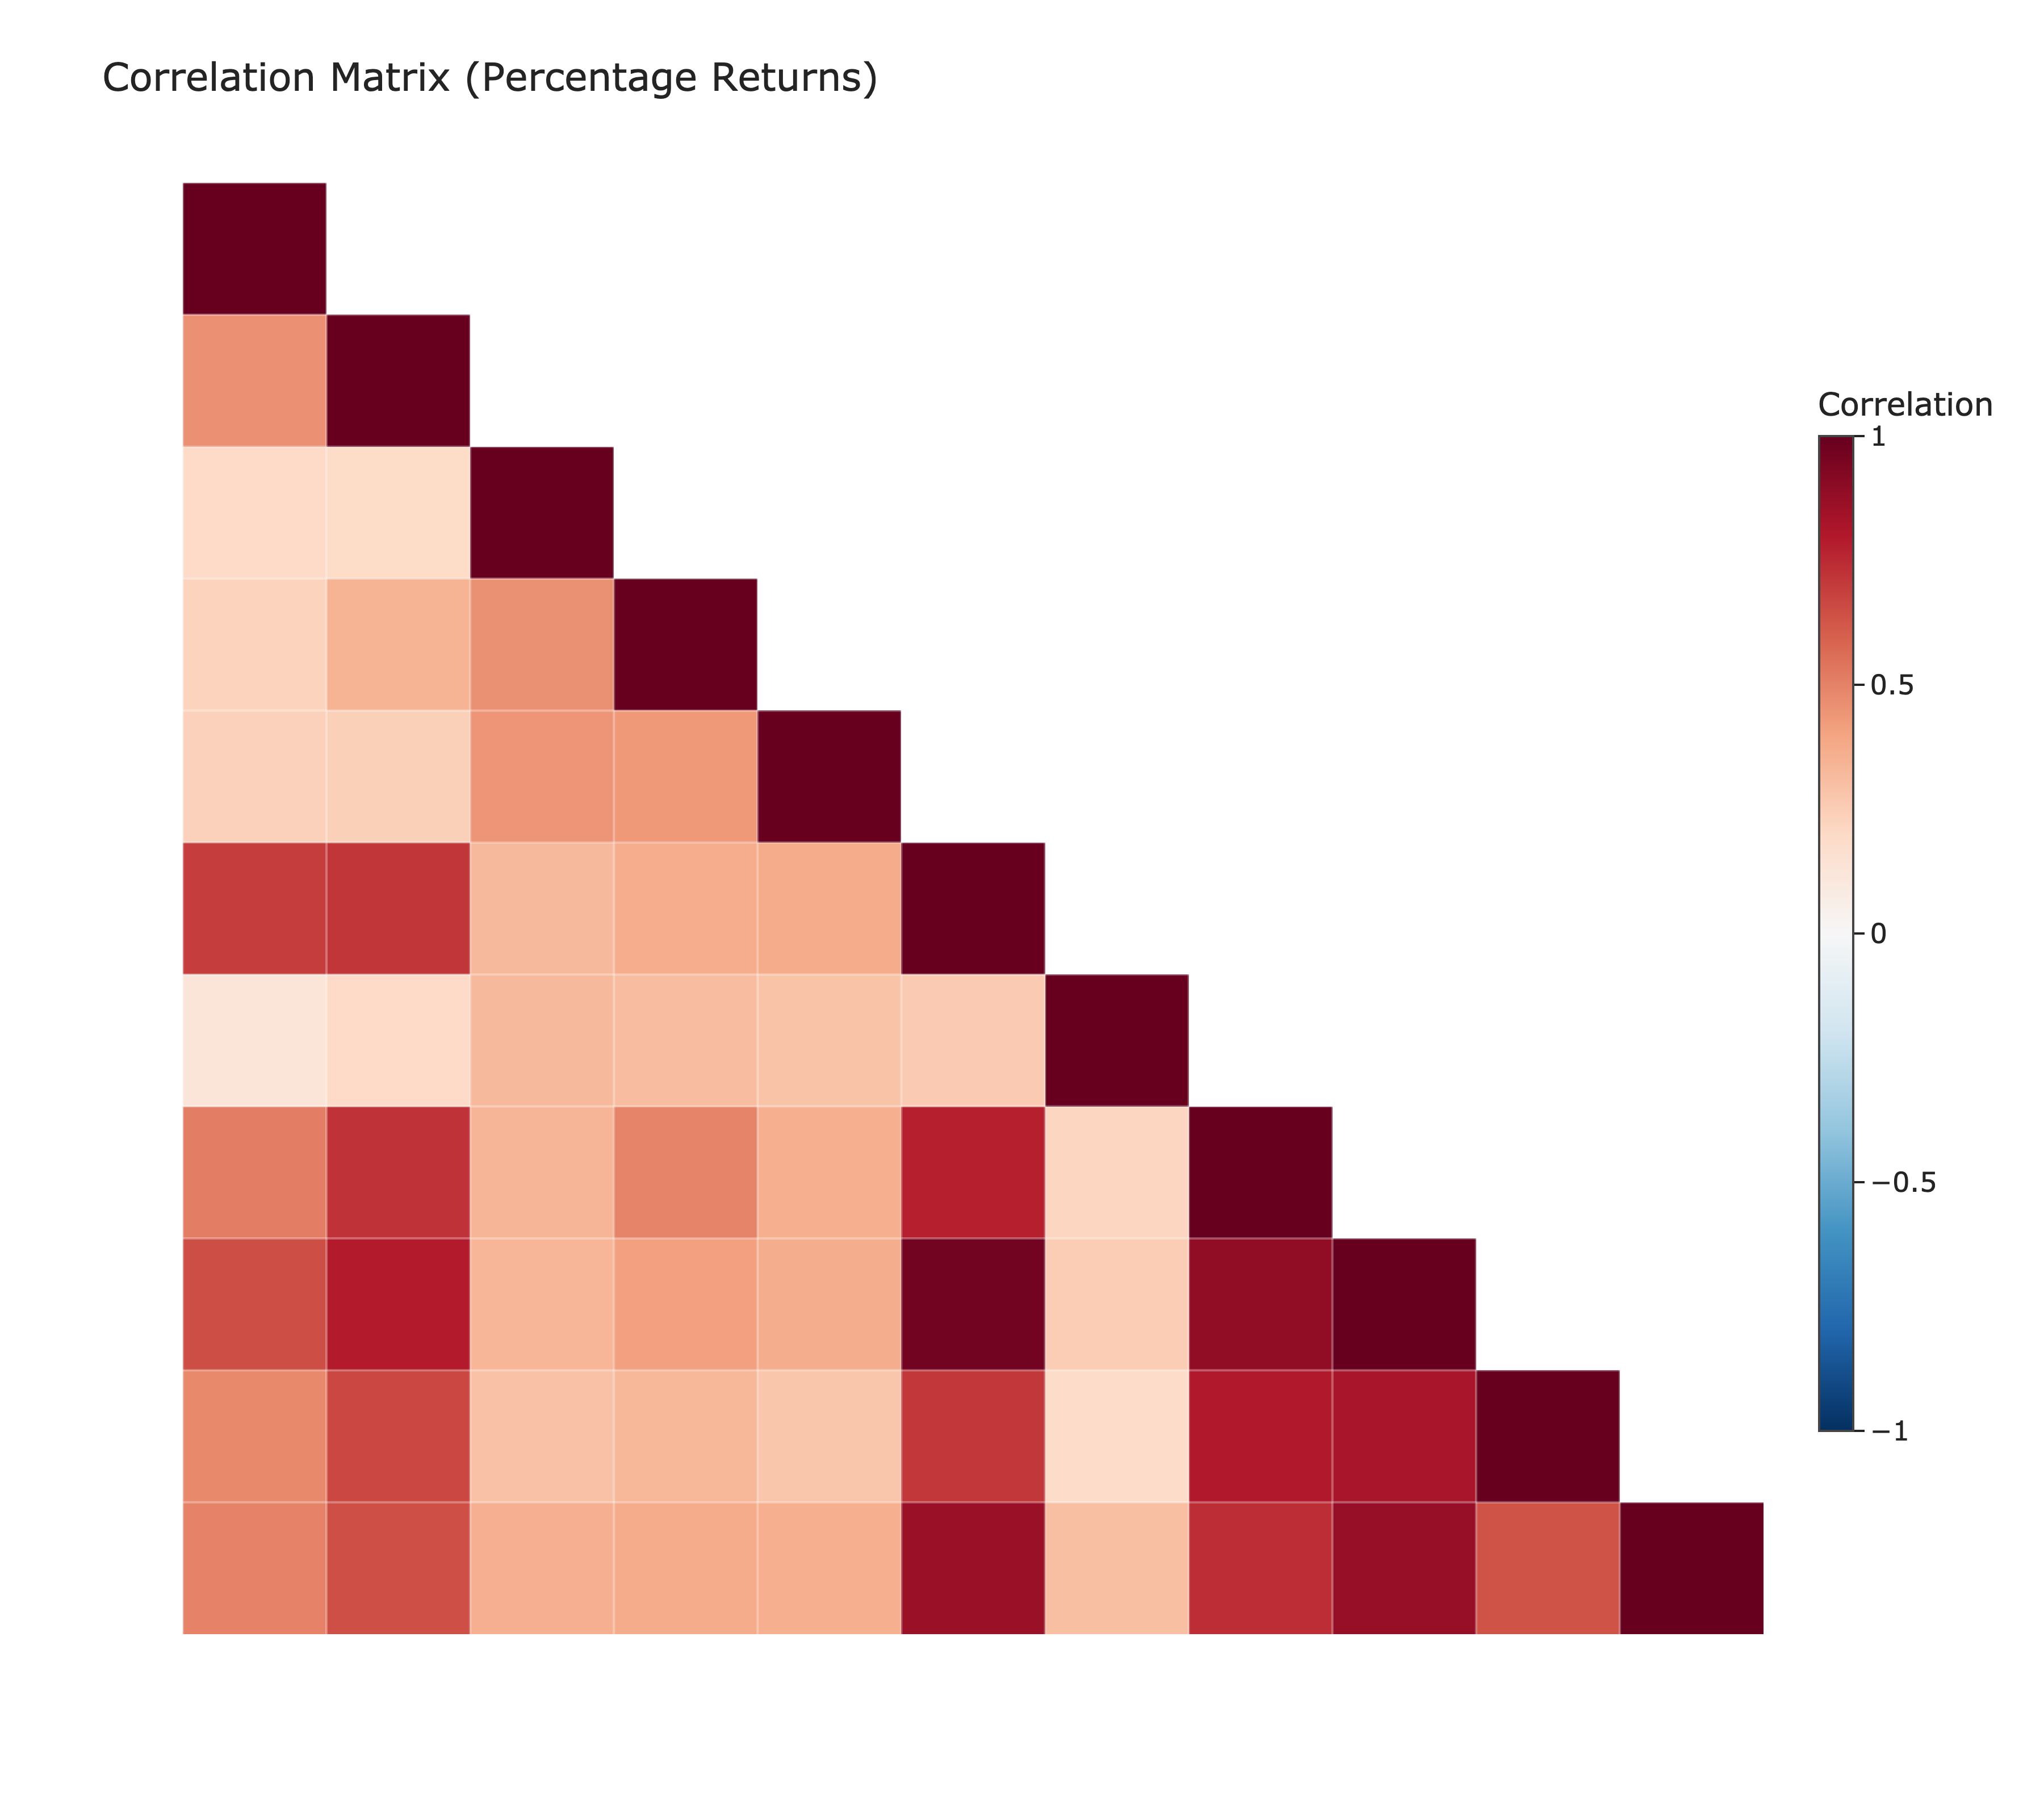

In [17]:
pv.plot_correlation_matrix(portfolio_matrix, interactive=False)

In [18]:
portfolio_matrix.tail()

,AAPL,EWJ,JNJ,NVS,PG,SPY,UNH,VGK,VT,VWO,XLI
Date,,,,,,,,,,,
2024-12-24,11571.335187,2368.956681,6444.811080,2555.849567,5997.319403,42963.359906,17983.563021,3382.113663,12802.314449,2404.056728,-3594.149135
2024-12-26,11620.356641,2398.941292,6439.681748,2559.852947,6047.016898,43011.656968,18182.212443,3394.694253,12830.841531,2400.685620,-3600.631118
2024-12-27,11459.847524,2415.744774,6412.527622,2558.112730,6021.144452,42534.281923,18130.460765,3381.614726,12722.838569,2390.701805,-3571.745932
2024-12-30,11344.835583,2403.249158,6357.656070,2538.829686,5953.893739,42186.427518,18111.649528,3370.368576,12640.993732,2377.500427,-3547.395061
2024-12-31,11282.253233,2404.829490,6424.387178,2542.248472,5983.122385,42098.205949,18070.464940,3376.133050,12631.587685,2377.412469,-3548.593034


In [19]:
portfolio_returns.tail()

,AAPL,EWJ,JNJ,NVS,PG,SPY,UNH,VGK,VT,VWO,XLI
Date,,,,,,,,,,,
2024-12-24,0.017617,0.005464,0.010086,0.005047,0.011036,0.017251,0.005592,0.011608,0.014032,0.010130,0.013929
2024-12-26,0.004236,0.012657,-0.000796,0.001566,0.008287,0.001124,0.011046,0.003720,0.002228,-0.001402,0.001803
2024-12-27,-0.013813,0.007005,-0.004217,-0.000680,-0.004279,-0.011099,-0.002846,-0.003853,-0.008417,-0.004159,-0.008022
2024-12-30,-0.010036,-0.005173,-0.008557,-0.007538,-0.011169,-0.008178,-0.001038,-0.003326,-0.006433,-0.005522,-0.006818
2024-12-31,-0.005516,0.000658,0.010496,0.001347,0.004909,-0.002091,-0.002274,0.001710,-0.000744,-0.000037,0.000338


If you want to **save the DataFrame shown above**, use:

```python
portfolio_returns.to_csv("portfolio_returns.csv")
```

If you want to **import your own CSV**, make sure the first column contains dates and use:

```python
df = pd.read_csv("your_file.csv", index_col=0, parse_dates=True)
```

This ensures:
- The first column becomes the date index
- Dates are properly parsed for the analysis

Note: You are responsible for data cleaning and pre-processing when using your own files. Our data-download functions will print warnings if there are issues, but they do not perform automatic cleaning.

In [20]:
# Use existing spot prices and volatilities
S0 = prices_chf.iloc[-1]
volatility_annualized = portfolio_returns.std() * np.sqrt(252)

# Select representative tickers for options
selected_tickers = ["VT", "SPY", "AAPL", "JNJ", "XLI"]

# Create example option contracts
options = [
    {
        "asset_index": tickers.index("AAPL"),
        "K": 200,
        "T": 60 / 252,
        "r": 0.01,
        "sigma": volatility_annualized["AAPL"],
        "type": "call",
        "quantity": 3000,         # number of contracts
        "contract_size": 100         # unit size per contract
    },
    {
        "asset_index": tickers.index("XLI"),
        "K": 115,
        "T": 45 / 252,
        "r": 0.01,
        "sigma": volatility_annualized["XLI"],
        "type": "put",
        "quantity": 5000,
        "contract_size": 100
    },
    {
        "asset_index": tickers.index("VT"),
        "K": 100,
        "T": 90 / 252,
        "r": 0.01,
        "sigma": volatility_annualized["VT"],
        "type": "call",
        "quantity": 2500,
        "contract_size": 100
    }
]

In [21]:
# Print values of equity positions (already defined)
print("\nEquity Positions (latest prices):")
total_equity_value = 0
for tkr in tickers:
    position_value = shares[tkr] * S0[tkr]
    print(f"{tkr:5}: {shares[tkr]:4} × {S0[tkr]:.2f} = {position_value:,.2f} CHF")
    total_equity_value += position_value

# Price and print values of options
print("\nOption Values (Black-Scholes at time 0):")
total_option_value = 0
for i, opt in enumerate(options):
    spot = S0[tickers[opt["asset_index"]]]
    price_bs = pv.black_scholes_pricing(
        spot, opt["K"], opt["T"], opt["r"], opt["sigma"], opt["type"]
    )
    option_value = price_bs * opt["quantity"] * opt["contract_size"]
    print(f"Option {i+1} on {tickers[opt['asset_index']]} ({opt['type']}): "
          f"BS = {price_bs:.2f} × {opt['quantity']} × {opt['contract_size']} = {option_value:,.2f} CHF")
    total_option_value += option_value

# Print new portfolio value
total_portfolio_value = total_equity_value + total_option_value
print(f"\nTotal equity value:     {total_equity_value:,.2f} CHF")
print(f"Total option value:     {total_option_value:,.2f} CHF")
print(f"Total portfolio value:  {total_portfolio_value:,.2f} CHF")


Equity Positions (latest prices):
VT   :  120 × 105.26 = 12,631.59 CHF
SPY  :   80 × 526.23 = 42,098.21 CHF
VGK  :   60 × 56.27 = 3,376.13 CHF
EWJ  :   40 × 60.12 = 2,404.83 CHF
VWO  :   60 × 39.62 = 2,377.41 CHF
AAPL :   50 × 225.65 = 11,282.25 CHF
JNJ  :   50 × 128.49 = 6,424.39 CHF
PG   :   40 × 149.58 = 5,983.12 CHF
UNH  :   40 × 451.76 = 18,070.46 CHF
NVS  :   30 × 84.74 = 2,542.25 CHF
XLI  :  -30 × 118.29 = -3,548.59 CHF

Option Values (Black-Scholes at time 0):
Option 1 on AAPL (call): BS = 27.80 × 3000 × 100 = 8,340,662.80 CHF
Option 2 on XLI (put): BS = 1.81 × 5000 × 100 = 902,881.78 CHF
Option 3 on VT (call): BS = 7.13 × 2500 × 100 = 1,781,738.44 CHF

Total equity value:     103,642.05 CHF
Total option value:     11,025,283.02 CHF
Total portfolio value:  11,128,925.07 CHF


### Historical Bootstrap Simulation (HBS)

Here we apply the **Historical Bootstrap Simulation (HBS)** method exactly as implemented in the `simulations.ipynb` notebook. This method resamples past return vectors with replacement to generate new simulated profit-and-loss outcomes, preserving the empirical distribution without assuming any parametric structure.

For a deeper discussion of the HBS methodology and its interpretation, refer to the **simulations notebook**.


In [22]:
# General simulations parameters
simulations = 10_000
seed = 1

In [23]:
# Bootstrapped Historical Simulation 
var_historical_bootstrap, pnl_historical_bootstrap = pv.historical_simulation_var(
    price_data=prices_chf,
    shares=shares.values,
    options=options,
    confidence_level=confidence_level,
    bootstrap=True,
    simulations=simulations,
    seed=seed
)

# ES
es_historical_bootstrap = pv.simulation_es(var_historical_bootstrap, pnl_historical_bootstrap)

# Print results
print(f"Bootstrapped Historical VaR (99%):   {var_historical_bootstrap:,.2f} CHF")
print(f"Bootstrapped Historical ES  (99%):   {es_historical_bootstrap:,.2f} CHF")

Bootstrapped Historical VaR (99%):   4,319,546.34 CHF
Bootstrapped Historical ES  (99%):   5,566,599.63 CHF


### Filtered Historical Simulation (FHS)

Here we apply the **Filtered Historical Simulation (FHS)** exactly as in the `simulations.ipynb` notebook. Again, for a deeper discussion of FHS and its assumptions, refer to the **simulations notebook**.

In [24]:
# Run Filtered Historical Simulation (1-day horizon, 99% confidence)
var_fhs, pnl_fhs = pv.filtered_historical_simulation_var(
    price_data=prices_chf,
    shares=shares.values,
    options=options,
    confidence_level=confidence_level,
    bootstrap=True,
    simulations=simulations,
    seed=seed,
    p=1,
    q=1,
    model="GJR",         # or "EGARCH", "GJR", "APARCH"
    distribution="skewt"  # or "t", "ged", "skewt"
)

# Calculate ES
es_fhs = pv.simulation_es(var_fhs, pnl_fhs)

# Display results
print(f"Filtered Historical Simulation VaR (99%):   {var_fhs:,.2f} CHF")
print(f"Filtered Historical Simulation ES  (99%):   {es_fhs:,.2f} CHF")

Filtered Historical Simulation VaR (99%):   5,768,749.55 CHF
Filtered Historical Simulation ES  (99%):   6,848,654.36 CHF


### Applying EVT on Simulated Profit and Loss

In [25]:
# New EVT parameters
new_confidence_level=0.9997
new_threshold_percentile=97.5

In [26]:
# Apply EVT on Historical Bootstrap
var_evt_hbs = pv.evt_var_simulations(
    profit_and_loss=pnl_historical_bootstrap,
    confidence_level=new_confidence_level,
    threshold_percentile=new_threshold_percentile
)

es_evt_hbs = pv.evt_es_simulations(
    profit_and_loss=pnl_historical_bootstrap,
    var_evt_simulations=var_evt_hbs,
    threshold_percentile=new_threshold_percentile
)

# Print results
print(f"EVT HBS VaR (99.97%):   {var_evt_hbs:,.2f} CHF")
print(f"EVT HBS ES  (99.97%):   {es_evt_hbs:,.2f} CHF")


EVT HBS VaR (99.97%):   7,415,046.70 CHF
EVT HBS ES  (99.97%):   7,584,208.24 CHF


In [27]:
# Apply EVT on FHS
var_evt_fhs = pv.evt_var_simulations(
    profit_and_loss=pnl_fhs,
    confidence_level=new_confidence_level,
    threshold_percentile=new_threshold_percentile
)

es_fhs_evt = pv.evt_es_simulations(
    profit_and_loss=pnl_fhs,
    var_evt_simulations=var_evt_fhs,
    threshold_percentile=new_threshold_percentile
)

# Print results
print(f"EVT FHS VaR (99.97%):   {var_evt_fhs:,.2f} CHF")
print(f"EVT FHS ES  (99.97%):   {es_fhs_evt:,.2f} CHF")

EVT FHS VaR (99.97%):   6,436,372.09 CHF
EVT FHS ES  (99.97%):   6,570,583.13 CHF


#### Results Comparison

With the updated EVT fits, both HBS and FHS have **similar exceedance counts** (232 vs 239), but differ sharply in their **tail characteristics**. The **FHS model** has a **heavier tail** ($\xi = 1.05$ vs $0.66$), indicating greater theoretical tail risk. However, the **EVT-adjusted VaR and ES are higher for HBS** (e.g., VaR: 7.41M CHF vs 6.44M CHF).

This counterintuitive result is driven by the **lower threshold** used in HBS (~3.93M CHF vs ~5.00M CHF), which causes the tail fit to start earlier and incorporate more moderate large losses. As a result, EVT inflates the tail estimates more aggressively despite the lower shape. This highlights how **threshold placement** can outweigh tail heaviness when estimating risk at extreme quantiles.

In [28]:
# EVT parameters for HBS
evt_params_hbs = pv.fit_evt_parameters(pnl_historical_bootstrap, threshold_percentile=new_threshold_percentile)

print("\n--- EVT Parameters: HBS ---")
print(f"Shape (xi):              {evt_params_hbs['xi']:.4f}")
print(f"Scale (beta):            {evt_params_hbs['beta']:.4f}")
print(f"Threshold (u):           {evt_params_hbs['threshold_u']:,.2f} CHF")
print(f"Exceedances:             {evt_params_hbs['num_exceedances']} out of {evt_params_hbs['total_observations']}")

# EVT parameters for FHS
evt_params_fhs = pv.fit_evt_parameters(pnl_fhs, threshold_percentile=new_threshold_percentile)

print("\n--- EVT Parameters: FHS ---")
print(f"Shape (xi):              {evt_params_fhs['xi']:.4f}")
print(f"Scale (beta):            {evt_params_fhs['beta']:.4f}")
print(f"Threshold (u):           {evt_params_fhs['threshold_u']:,.2f} CHF")
print(f"Exceedances:             {evt_params_fhs['num_exceedances']} out of {evt_params_fhs['total_observations']}")



--- EVT Parameters: HBS ---
Shape (xi):              0.6626
Scale (beta):            350453.0180
Threshold (u):           3,929,934.17 CHF
Exceedances:             232 out of 10000

--- EVT Parameters: FHS ---
Shape (xi):              1.0515
Scale (beta):            290195.3774
Threshold (u):           5,000,581.95 CHF
Exceedances:             239 out of 10000


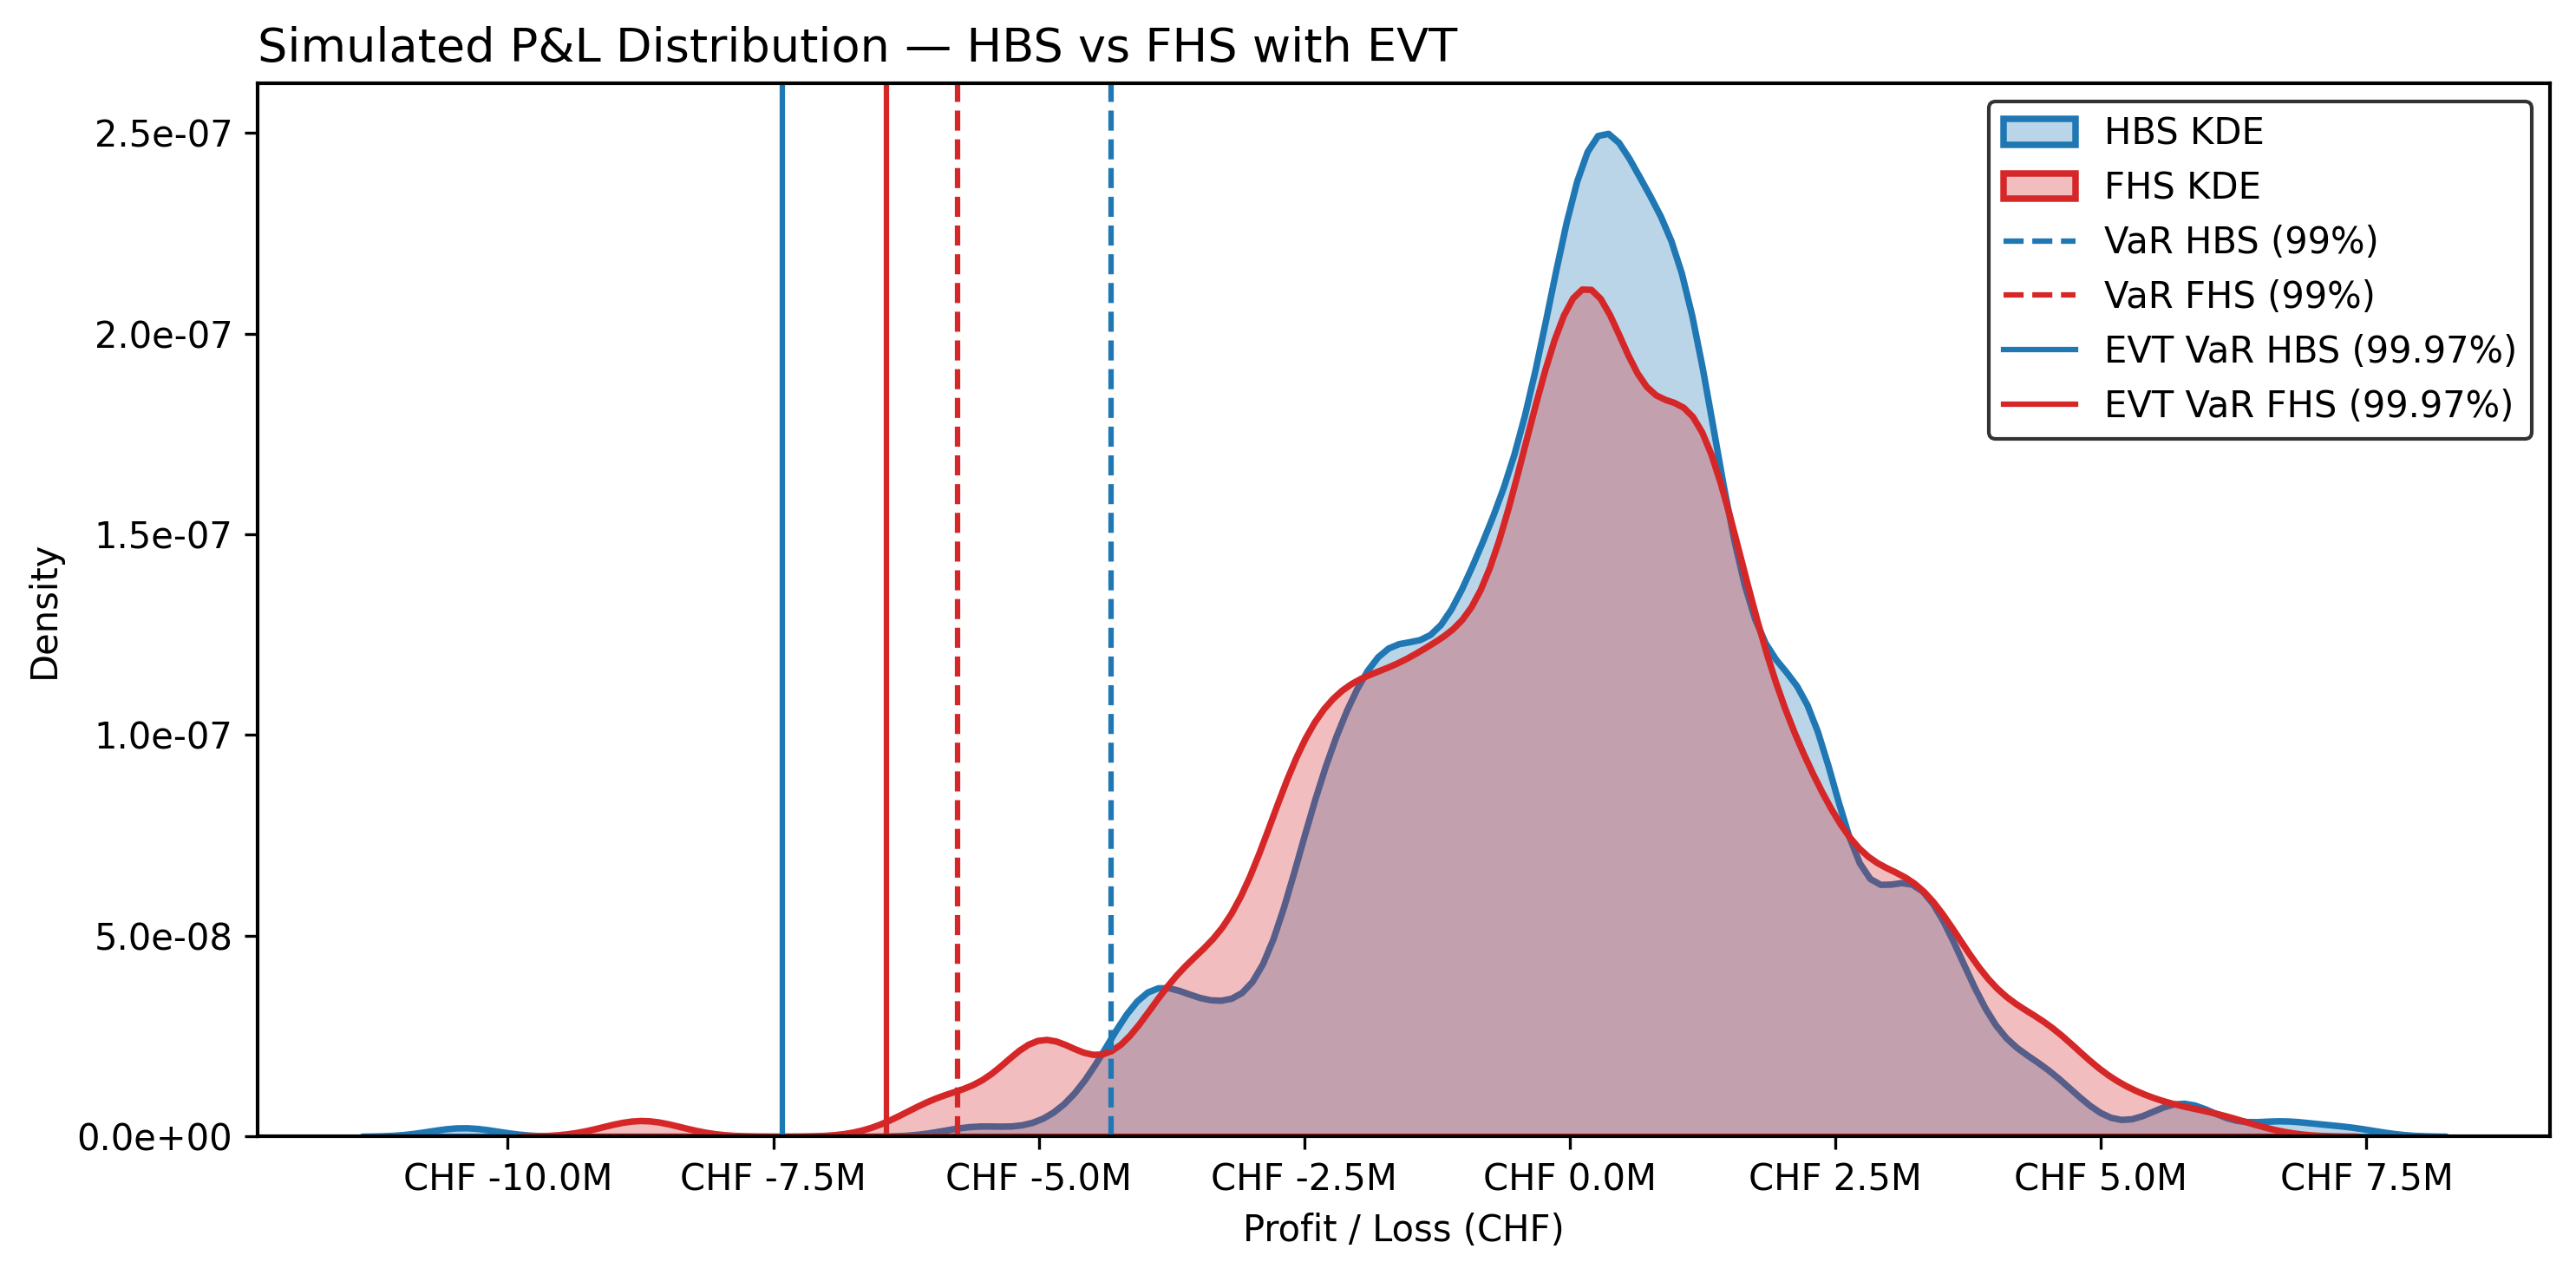

In [29]:
plt.figure(figsize=(10, 5), dpi=300)

# KDE plots
sns.kdeplot(pnl_historical_bootstrap, label="HBS KDE", fill=True, color="#1f77b4", linewidth=1.8, alpha=0.3)
sns.kdeplot(pnl_fhs, label="FHS KDE", fill=True, color="#d62728", linewidth=1.8, alpha=0.3)

# VaR lines: Standard
plt.axvline(-var_historical_bootstrap, color="#1f77b4", linestyle="--", linewidth=1.5, label="VaR HBS (99%)")
plt.axvline(-var_fhs, color="#d62728", linestyle="--", linewidth=1.5, label="VaR FHS (99%)")

# VaR lines: EVT
plt.axvline(-var_evt_hbs, color="#1f77b4", linestyle="-", linewidth=1.5, label="EVT VaR HBS (99.97%)")
plt.axvline(-var_evt_fhs, color="#d62728", linestyle="-", linewidth=1.5, label="EVT VaR FHS (99.97%)")

# Title and labels
plt.title("Simulated P&L Distribution — HBS vs FHS with EVT", loc="left", fontsize=13, fontweight="medium")
plt.xlabel("Profit / Loss (CHF)")
plt.ylabel("Density")

# Axis styling
ax = plt.gca()
for side in ["top", "bottom", "left", "right"]:
    ax.spines[side].set_visible(True)
    ax.spines[side].set_color("black")
    ax.spines[side].set_linewidth(1)

ax.tick_params(width=0.8, color='black')

# Format axes
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"CHF {x/1e6:.1f}M"))
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{y:.1e}"))

# Legend
plt.legend(frameon=True, edgecolor="black")
plt.tight_layout()
plt.show()